# Session 2 — Mini-projet intégrateur Churn Predictor (MATIN)
## Phases 1 & 2 : Pipeline pro & course de modèles

**Durée matin : 3h** (2 phases + 1 pause)

---

### 🎬 La narration de la journée

Vous avez fini la session 1 avec un baseline régression logistique honnête mais perfectible. Aujourd'hui, on passe en mode **mini-projet intégrateur** : à 16h, vous aurez identifié, justifié et sauvegardé le **best model** pour ce problème churn — tuné, traçable, avec un seuil métier optimisé.

**Trame de la journée**

| Bloc | Phase | Objectif |
|------|-------|----------|
| Matin (3h) | **1. Pipeline pro & FE** + **2. Course de modèles** | Identifier les 2 modèles à tuner |
| Pause déjeuner | — | — |
| Après-midi (2h15) | **3. Tuning + seuil métier** + **4. Best model & éval finale** | Best model sauvegardé |

### 🎯 Objectifs d'apprentissage du matin

À la fin du matin, vous saurez :
- Construire des **features ingénierées** sur un dataset tabulaire.
- Faire de la **cross-validation stratifiée** propre avec plusieurs métriques.
- **Tracker des expériences ML avec MLflow** (params, metrics, comparaison).
- Comparer rigoureusement **plusieurs familles de modèles** (linéaire, arbres, ensembles, boosting).
- Lire la **variance entre folds** comme indicateur de stabilité du modèle.


## Phase 1 — Du baseline à un pipeline pro (1h15)

🎯 **Sous-objectifs**
- Reprendre le baseline S1 et construire 4 features ingénierées.
- Reconstruire le `ColumnTransformer` étendu.
- Mettre en place une cross-validation 5-fold stratifiée multi-métriques.
- Premier run MLflow avec params + metrics.

### 1.0 Setup & rechargement des splits

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression

import mlflow
import mlflow.sklearn

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


In [2]:
X_train = pd.read_csv("data/X_train.csv")
X_val   = pd.read_csv("data/X_val.csv")
X_test  = pd.read_csv("data/X_test.csv")
y_train = pd.read_csv("data/y_train.csv")["Churn"]
y_val   = pd.read_csv("data/y_val.csv")["Churn"]
y_test  = pd.read_csv("data/y_test.csv")["Churn"]

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Churn rates → train: {y_train.mean():.2%} | val: {y_val.mean():.2%} | test: {y_test.mean():.2%}")


Train: (4930, 19) | Val: (1056, 19) | Test: (1057, 19)
Churn rates → train: 26.53% | val: 26.52% | test: 26.58%


### 1.1 Recap baseline S1

Un coup d'œil rapide : on refit la régression logistique de S1 pour avoir le **score plancher** de la journée. C'est ce qu'il faudra battre.

In [3]:
from sklearn.metrics import f1_score, average_precision_score

num_cols_orig = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols_orig = X_train.select_dtypes(include="object").columns.tolist()

baseline_preprocessor = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num_cols_orig),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("ohe", OneHotEncoder(handle_unknown="ignore"))]), cat_cols_orig),
])

baseline_model = Pipeline([("prep", baseline_preprocessor),
                           ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
baseline_model.fit(X_train, y_train)
baseline_proba = baseline_model.predict_proba(X_val)[:, 1]
baseline_pred = baseline_model.predict(X_val)

print(f"Baseline LogReg @ threshold=0.5:")
print(f"  F1:     {f1_score(y_val, baseline_pred):.4f}")
print(f"  PR-AUC: {average_precision_score(y_val, baseline_proba):.4f}")
print("→ This is the floor we need to beat today.")


Baseline LogReg @ threshold=0.5:
  F1:     0.6182
  PR-AUC: 0.6309
→ This is the floor we need to beat today.


### 1.2 Feature engineering

On va créer **4 features ingénierées** qui capturent des signaux que les features brutes ratent :

| Feature | Type | Intuition |
|---------|------|-----------|
| `tenure_group` | catégoriel | Bin de tenure (`new`, `mid`, `loyal`) — capture les non-linéarités pour les modèles linéaires. |
| `services_count` | numérique | Nombre de services premium souscrits → engagement client. |
| `has_internet` | numérique (0/1) | Dérivée de `InternetService` — utile pour aplatir une catégorie complexe. |
| `avg_charge_per_month` | numérique | Robuste à `tenure=0` (division protégée), capture le "tarif moyen vécu". |

🧠 **Réflexe Tech Lead** : on encapsule la création des features dans une **fonction réutilisable**. Le jour où on industrialise, ça devient un transformer scikit-learn ou une fonction du package.

In [4]:
SERVICE_COLS = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
]

def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add 4 engineered features. Returns a NEW DataFrame."""
    df = df.copy()
    
    # tenure_group : bins new / mid / loyal
    df["tenure_group"] = pd.cut(
        df["tenure"],
        bins=[-1, 12, 36, 1000],
        labels=["new", "mid", "loyal"],
    )
    
    # services_count : nombre de services premium actifs
    df["services_count"] = (df[SERVICE_COLS] == "Yes").sum(axis=1)
    
    # has_internet : 1 si l'abonné a internet, 0 sinon
    df["has_internet"] = (df["InternetService"] != "No").astype(int)
    
    # avg_charge_per_month : charge mensuelle moyenne (protégé contre tenure=0)
    df["avg_charge_per_month"] = df["TotalCharges"] / np.maximum(df["tenure"], 1)
    
    return df


# Application aux trois splits
X_train_fe = add_engineered_features(X_train)
X_val_fe   = add_engineered_features(X_val)
X_test_fe  = add_engineered_features(X_test)

print(f"Original cols: {X_train.shape[1]} → After FE: {X_train_fe.shape[1]}")
X_train_fe.head(3)


Original cols: 19 → After FE: 23


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,tenure_group,services_count,has_internet,avg_charge_per_month
0,Female,0,No,No,5,Yes,No,Fiber optic,No,No,...,No,Month-to-month,No,Electronic check,80.20,384.25,new,1,1,76.85
1,Female,1,No,No,3,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,86.85,220.95,new,2,1,73.65
2,Female,0,Yes,No,3,Yes,Yes,Fiber optic,No,No,...,No,Month-to-month,Yes,Credit card (automatic),75.15,216.75,new,0,1,72.25


💡 **Validation rapide** : on vérifie que les distributions sont cohérentes.

In [5]:
# Quick sanity checks
print("tenure_group distribution:")
print(X_train_fe["tenure_group"].value_counts())
print("\nservices_count stats:")
print(X_train_fe["services_count"].describe())
print("\nChurn rate by tenure_group:")
print(X_train_fe.assign(churn=y_train.values)
      .groupby("tenure_group", observed=True)["churn"].mean())


tenure_group distribution:
tenure_group
loyal    2112
new      1537
mid      1281
Name: count, dtype: int64

services_count stats:
count    4930.000000
mean        2.066531
std         1.861080
min         0.000000
25%         0.000000
50%         2.000000
75%         3.000000
max         6.000000
Name: services_count, dtype: float64

Churn rate by tenure_group:
tenure_group
new      0.476903
mid      0.241218
loyal    0.125947
Name: churn, dtype: float64


### 1.3 Pipeline étendu

On reconstruit le `ColumnTransformer` en intégrant les nouvelles features. Le code est **identique** au S1 — seules les listes de colonnes changent.

In [6]:
# Colonnes numériques et catégorielles depuis X_train_fe
num_cols = X_train_fe.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train_fe.select_dtypes(include="object").columns.tolist()

print(f"Numeric ({len(num_cols)}): {num_cols}")
print(f"Categorical ({len(cat_cols)}): {cat_cols}")

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc", StandardScaler()),
    ]), num_cols),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]), cat_cols),
])


Numeric (7): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'services_count', 'has_internet', 'avg_charge_per_month']
Categorical (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### 1.4 Cross-validation stratifiée multi-métriques

Pourquoi passer du simple split val à la CV ?
- **Robustesse** : un seul split val peut être chanceux. La CV répète l'évaluation sur 5 folds différents.
- **Variance** : on obtient une moyenne ET un écart-type. Un modèle qui fait 0.65 ± 0.02 est plus fiable qu'un modèle qui fait 0.65 ± 0.10.
- **Standard métier** : tout reporting ML sérieux utilise une CV.

⚠️ On utilise **StratifiedKFold** pour conserver le taux de churn dans chaque fold.

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

logreg_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

cv_results = cross_validate(
    logreg_pipe, X_train_fe, y_train, cv=cv,
    scoring=["f1", "roc_auc", "average_precision"],
    n_jobs=2,
)

for metric in ["f1", "roc_auc", "average_precision"]:
    scores = cv_results[f"test_{metric}"]
    print(f"{metric:>20s}: {scores.mean():.4f} ± {scores.std():.4f}")


                  f1: 0.5931 ± 0.0247
             roc_auc: 0.8441 ± 0.0116
   average_precision: 0.6597 ± 0.0208


### 1.5 Intro MLflow : tracker les expériences

🧠 **Pourquoi MLflow ?** En tant que Tech Lead, vous serez confronté à des collègues qui font 50 expériences en mémoire et ne se souviennent plus laquelle a donné quel score. MLflow vous donne :
- **Reproductibilité** : chaque run logue ses params + metrics + le modèle.
- **Comparabilité** : interface web pour comparer N runs (`mlflow ui`).
- **Auditabilité** : qui a entraîné quoi, quand, avec quels paramètres.

C'est un outil **basique mais essentiel**. Pas de MLflow = pas de gestion d'expériences = pas de Tech Lead ML.

#### Setup
On utilise un backend local (fichiers dans `./mlruns/`).

In [8]:
# Local backend — perfect for solo work
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("churn-models-zoo")

# Log the LogReg run we just did
with mlflow.start_run(run_name="logreg_baseline_with_FE"):
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("with_engineered_features", True)
    
    for metric in ["f1", "roc_auc", "average_precision"]:
        scores = cv_results[f"test_{metric}"]
        mlflow.log_metric(f"{metric}_mean", scores.mean())
        mlflow.log_metric(f"{metric}_std", scores.std())
    
    mlflow.log_metric("fit_time_mean", cv_results["fit_time"].mean())

print("✅ Run logged to MLflow.")
print("→ To open the MLflow UI later, run in your terminal: mlflow ui")


2026/05/13 10:05:31 INFO mlflow.tracking.fluent: Experiment with name 'churn-models-zoo' does not exist. Creating a new experiment.


✅ Run logged to MLflow.
→ To open the MLflow UI later, run in your terminal: mlflow ui


---
## ⛳ JALON Phase 1 — Validez avant de passer à la suite

À ce stade, vous avez :
- ✅ 4 features ingénierées propres et réutilisables.
- ✅ Un `Pipeline` étendu avec le nouveau `ColumnTransformer`.
- ✅ Une cross-validation stratifiée 5-fold multi-métriques.
- ✅ Un setup MLflow fonctionnel + un premier run loggé.

Si l'un de ces points cloche, **reprenez maintenant** avant de continuer.

🛑 **Pause de 15 minutes**. Au retour : on lance la course de 5 modèles.

---

## Phase 2 — Course de modèles & comparaison rigoureuse (1h45)

🎯 **Sous-objectifs**
- Tester 5 familles de modèles dans le même cadre CV + MLflow.
- Construire un **tableau comparatif** propre.
- Lire la **variance entre folds** pour évaluer la stabilité.
- Choisir les **2 modèles** qu'on tunera cet après-midi.

### 2.1 Helper d'évaluation

Pour ne pas dupliquer le code 5 fois, on écrit une **fonction** qui :
1. Construit le pipeline (preproc + classifieur)
2. Lance la CV multi-métriques
3. Logue dans MLflow (params + metrics + per-fold scores)
4. Retourne les scores pour analyse

C'est l'outil de productivité le plus important de la journée — on va l'appeler 5 fois.

In [9]:
from sklearn.metrics import make_scorer

def evaluate_model_cv(name: str, classifier, X, y, cv, preprocessor,
                      params_to_log: dict = None):
    """Train-validate `classifier` via CV, log everything to MLflow.
    Returns the cv_results dict."""
    pipe = Pipeline([("prep", preprocessor), ("clf", classifier)])
    
    t0 = time.perf_counter()
    cv_results = cross_validate(
        pipe, X, y, cv=cv,
        scoring=["f1", "roc_auc", "average_precision"],
        n_jobs=2,
    )
    elapsed = time.perf_counter() - t0
    
    with mlflow.start_run(run_name=name):
        mlflow.log_param("model", name)
        if params_to_log:
            for k, v in params_to_log.items():
                mlflow.log_param(k, v)
        
        for metric in ["f1", "roc_auc", "average_precision"]:
            scores = cv_results[f"test_{metric}"]
            mlflow.log_metric(f"{metric}_mean", scores.mean())
            mlflow.log_metric(f"{metric}_std", scores.std())
            for i, s in enumerate(scores):
                mlflow.log_metric(f"{metric}_fold", s, step=i)
        
        mlflow.log_metric("total_time_s", elapsed)
    
    f1 = cv_results["test_f1"]
    pr = cv_results["test_average_precision"]
    print(f"{name:>30s} | F1: {f1.mean():.4f}±{f1.std():.4f} | "
          f"PR-AUC: {pr.mean():.4f}±{pr.std():.4f} | time: {elapsed:.1f}s")
    return cv_results


### 2.2 Modèle 1 — Régression logistique (rappel baseline)

In [10]:
results_logreg = evaluate_model_cv(
    name="LogisticRegression",
    classifier=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X=X_train_fe, y=y_train, cv=cv, preprocessor=preprocessor,
    params_to_log={"max_iter": 1000},
)


            LogisticRegression | F1: 0.5931±0.0247 | PR-AUC: 0.6597±0.0208 | time: 0.1s


### 2.3 Modèle 2 — Arbre de décision

🧠 **Pourquoi tester un arbre seul ?** Référence pour les ensembles. Un arbre seul **overfit** typiquement → le voir performer moins que les ensembles fait passer le message naturellement.

In [11]:
from sklearn.tree import DecisionTreeClassifier

results_dt = evaluate_model_cv(
    name="DecisionTree",
    classifier=DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    X=X_train_fe, y=y_train, cv=cv, preprocessor=preprocessor,
    params_to_log={"max_depth": 8},
)


                  DecisionTree | F1: 0.5504±0.0184 | PR-AUC: 0.5362±0.0337 | time: 0.2s


### 2.4 Modèle 3 — Random Forest

In [12]:
from sklearn.ensemble import RandomForestClassifier

results_rf = evaluate_model_cv(
    name="RandomForest",
    classifier=RandomForestClassifier(n_estimators=200, max_depth=None,
                                      random_state=RANDOM_STATE, n_jobs=-1),
    X=X_train_fe, y=y_train, cv=cv, preprocessor=preprocessor,
    params_to_log={"n_estimators": 200, "max_depth": None},
)


                  RandomForest | F1: 0.5632±0.0118 | PR-AUC: 0.6342±0.0214 | time: 0.9s


### 2.5 Modèle 4 — Gradient Boosting

In [13]:
from sklearn.ensemble import GradientBoostingClassifier

results_gbm = evaluate_model_cv(
    name="GradientBoosting",
    classifier=GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                          max_depth=3, random_state=RANDOM_STATE),
    X=X_train_fe, y=y_train, cv=cv, preprocessor=preprocessor,
    params_to_log={"n_estimators": 100, "learning_rate": 0.1, "max_depth": 3},
)


              GradientBoosting | F1: 0.5854±0.0127 | PR-AUC: 0.6615±0.0220 | time: 1.7s


### 2.6 Modèle 5 — Histogram Gradient Boosting

🧠 **Pourquoi `HistGradientBoostingClassifier` ?** Variante moderne de scikit-learn, **10× plus rapide** que `GradientBoostingClassifier` sur les gros datasets, équivalente à LightGBM/XGBoost en pratique. C'est le "go-to" en 2026 quand on veut un boosting performant sans dépendance externe.

In [14]:
from sklearn.ensemble import HistGradientBoostingClassifier

results_hgbt = evaluate_model_cv(
    name="HistGradientBoosting",
    classifier=HistGradientBoostingClassifier(max_iter=200, learning_rate=0.1,
                                              max_depth=None, random_state=RANDOM_STATE),
    X=X_train_fe, y=y_train, cv=cv, preprocessor=preprocessor,
    params_to_log={"max_iter": 200, "learning_rate": 0.1, "max_depth": None},
)


          HistGradientBoosting | F1: 0.5641±0.0247 | PR-AUC: 0.6259±0.0275 | time: 5.9s


### 2.7 Comparaison rigoureuse

On lit MLflow pour récupérer tous les runs de cette expérience et on les classe.

In [15]:
runs = mlflow.search_runs(experiment_names=["churn-models-zoo"])
display_cols = [
    "tags.mlflow.runName",
    "metrics.f1_mean", "metrics.f1_std",
    "metrics.average_precision_mean", "metrics.average_precision_std",
    "metrics.total_time_s",
]
ranking = runs[display_cols].sort_values("metrics.f1_mean", ascending=False).reset_index(drop=True)
ranking.columns = ["model", "F1_mean", "F1_std", "PR-AUC_mean", "PR-AUC_std", "time_s"]
ranking


,model,F1_mean,F1_std,PR-AUC_mean,PR-AUC_std,time_s
0,LogisticRegression,0.593069,0.024654,0.659697,0.020752,0.119658
1,logreg_baseline_with_FE,0.593069,0.024654,0.659697,0.020752,NaN
2,GradientBoosting,0.585420,0.012697,0.661533,0.022031,1.692409
3,HistGradientBoosting,0.564070,0.024683,0.625903,0.027548,5.923772
4,RandomForest,0.563192,0.011770,0.634230,0.021416,0.857639
5,DecisionTree,0.550449,0.018420,0.536197,0.033671,0.161525


### 2.8 Visualisation : variance entre folds

Le score moyen ne dit pas tout. Un modèle peut avoir un F1 moyen élevé mais **très instable** entre folds — danger en prod où la donnée bouge.

On trace les scores par fold pour chaque modèle.

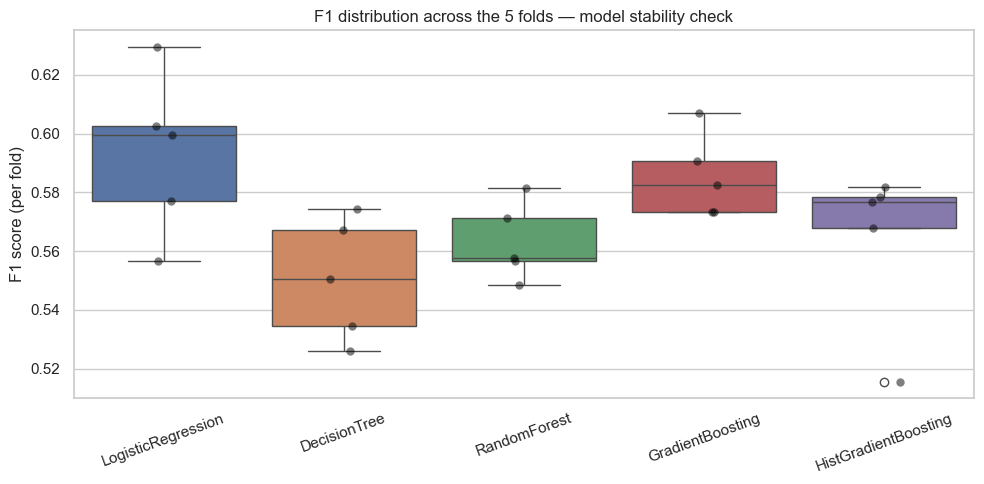

In [16]:
all_results = {
    "LogisticRegression": results_logreg["test_f1"],
    "DecisionTree": results_dt["test_f1"],
    "RandomForest": results_rf["test_f1"],
    "GradientBoosting": results_gbm["test_f1"],
    "HistGradientBoosting": results_hgbt["test_f1"],
}
df_scores = pd.DataFrame(all_results)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_scores, ax=ax)
sns.stripplot(data=df_scores, ax=ax, color="black", alpha=0.5, size=6)
ax.set_ylabel("F1 score (per fold)")
ax.set_title("F1 distribution across the 5 folds — model stability check")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### 2.9 Sauvegarde des splits featurisés

On persiste les splits avec FE pour pouvoir les recharger cet après-midi sans tout refaire.

In [17]:
Path("data").mkdir(exist_ok=True)
X_train_fe.to_csv("data/X_train_fe.csv", index=False)
X_val_fe.to_csv("data/X_val_fe.csv", index=False)
X_test_fe.to_csv("data/X_test_fe.csv", index=False)
print("Featurized splits saved to ./data/")


Featurized splits saved to ./data/


---
## ⛳ JALON MIDI — Choix des 2 modèles à tuner

🎯 **À remplir** :

> **Mes 2 candidats à tuner cet après-midi** :
>
> 1. **Modèle A** : GradientBoosting
>    Justification : meilleure stabilité inter-folds (F1_std = 0.013, le plus faible de tous), meilleur PR-AUC (0.662). Performances reproductibles fold après fold — exactement ce qu'on veut tuner.
>
> 2. **Modèle B** : LogisticRegression
>    Justification : meilleur F1 moyen (0.593), très rapide (< 0.2 s), interprétable. Assure la diversité linéaire / tree-based et sert de référence pour mesurer le gain réel du tuning.

💡 **Critères de choix attendus** :
- F1 / PR-AUC moyen élevé
- Variance inter-fold acceptable (pas de fold catastrophique)
- Diversité (mieux d'avoir 1 linéaire + 1 boosting que 2 boostings)
- Temps d'entraînement raisonnable (pour ne pas perdre l'après-midi)

🥪 **Pause déjeuner — 1h**

Au retour, on lance le notebook **après-midi** : `S2_apresmidi_tuning_best_model_etudiant.ipynb`.

---